# Camera Pose Optimization From Real Background-Run Data

**Status: first pass below -- loads one real single-bubble event and test-renders
its reconstructed 3D position against the real camera frame. Fiducial detection and
actually feeding real observations into the pose optimizer are still not started.**

Goal: use real chamber camera images (rather than rendered/synthetic ones) to refine the
camera pose estimates used elsewhere in this repo's rendering pipeline (`utils.py` /
`PoseMatrixEstimation.ipynb`), since the physical detector cameras may not sit exactly where
the current pose estimates assume.

## Data sources (read-only — never write/edit anything under these paths)

- **Background runs**: `~/coop/local-runs/20251114_37/` and `~/coop/local-runs/20251115_0/`
  - Each run contains numbered event directories (`<run>/<evNum>/`), e.g. `.../20251114_37/0/`
  - Each event directory has per-camera image sequences: `cam1-imgNN.png`, `cam2-imgNN.png`,
    `cam3-imgNN.png`, plus `camN-info.csv`, `camN.log`, and non-image DAQ files
    (`acoustics.sbc`, `digiscope.sbc`, `event_info.sbc`, `plc.sbc`, `slow_daq.sbc`).
- **Precomputed analysis outputs**: `~/coop/local-runs/<run>/analysis/*.sbc` (`event`, `exposure`,
  `reco`, `bubble`, `clustering`, `run`, ...) — already-reconstructed outputs (3D bubble
  positions, per-camera bubble detections, livetimes) local to this sandbox. Load with
  `real_data_loading.load_analysis(run_dir, name)`, no external analysis package needed.
- **Handscanned bubble multiplicity**: `~/coop/local-runs/<run>/handscan.txt`


## Plan (draft — not yet implemented)

1. Parse `handscan.txt` for each run to identify usable events (e.g. clean single/known-multiplicity
   bubble events) for calibration.
2. Load the corresponding `camN-imgNN.png` frames for those events.
3. Locate fiducials / bubble pixel positions in the real images (reuse or adapt detection helpers
   from `utils.py`, e.g. the Hough-circle approach used in `rendered_grid_projections`).
4. Feed real pixel observations into the existing pose-estimation / optimization utilities
   (`estimate_pose_matrix`, `gradient_descent_optimization`, `levenberg_marquardt_optimization`).
5. Compare the resulting optimized camera poses against the poses currently assumed by the
   rendering scene (`chamber_model/`, `PoseMatrixEstimation.ipynb` outputs in
   `outputs/estimated_pose_matrices/`) and quantify the discrepancy.
6. Decide whether/how to feed corrected poses back into the rendering setup.

Open questions to resolve before implementing:
- Notebook vs. plain script — leaning notebook to match the rest of the pose/triangulation
  workflow (`PoseMatrixEstimation.ipynb`, `PixelRemappingAndTriangulation_Multiple.ipynb`), but
  batch-processing many events across two runs may be cleaner as a `.py` module imported here.
- Which events/how many are actually usable for calibration (depends on handscan contents).
- What fiducial/reference features are visible and identifiable in the real images.

In [1]:
import os, sys
if not os.path.isdir("modules"):
    os.chdir("..")
sys.path.insert(0, "modules")

from utils import *
import real_data_loading as rdl

In [2]:
# Group every real-data render for a given event under
# outputs/<run>_ev<ev>/cam<camera>/frame<NN>/ instead of flat in outputs/<date>/, so a
# whole event's renders are easy to browse together. This still goes through render()'s
# own save_mono/save_rgb (same file-naming convention every notebook in this repo uses)
# -- it just relocates the two files it wrote right after it writes them.
def event_output_dir(run_name, ev, camera, frame):
    d = pathlib.Path(output_dir) / f"{run_name}_ev{ev}" / f"cam{camera}" / f"frame{frame:02d}"
    d.mkdir(parents=True, exist_ok=True)
    return d


def move_latest_render_outputs(tag, dest_dir, retries=20, delay=0.5):
    """Moves the mono/rgb files render() just wrote (matched by their unique
    save_string_append tag) out of outputs/<date>/ and into dest_dir. render()'s own
    'Saved Image' print can appear slightly before the file is actually flushed to disk
    (seen in practice), so this polls briefly instead of assuming it's already there."""
    date_dir = pathlib.Path(output_dir) / time.strftime('%Y_%m_%d')
    moved = {}
    for kind in ("mono", "rgb"):
        matches = []
        for _ in range(retries):
            matches = sorted(date_dir.glob(f"*_{kind}_{tag}.png"))
            if matches:
                break
            time.sleep(delay)
        if matches:
            dest = dest_dir / matches[-1].name
            matches[-1].rename(dest)
            moved[kind] = dest
        else:
            print(f"WARNING: no {kind} file found for tag {tag!r} after {retries * delay:.1f}s")
    try:
        date_dir.rmdir()  # tidy up render()'s now-empty outputs/<date>/ scratch dir
    except OSError:
        pass  # not empty (other renders landed here too) -- leave it alone
    return moved

In [3]:
# Pick a run and a clean single-bubble event (handscanned nbub == 1, crosshairs good),
# and load its per-camera pixel track and triangulated 3D reconstruction.
run_name = "20251114_37"
run_dir = rdl.RUN_DIRS[run_name]

ev = rdl.single_bubble_events(run_dir)[0]
tracks, t0_info = rdl.load_single_bubble_track(run_dir, ev)
reco = rdl.load_reco_single(run_dir, ev)

print(f"run {run_name}, event {ev}")
print(f"cameras with a track: {list(tracks.keys())}")
print(f"t0: {t0_info}")
print(f"frames with a valid 3D reco: {[r['frame'] for r in reco if r['coord'] is not None]}")

run 20251114_37, event 1
cameras with a track: [1, 2, 3]
t0: {'frame': 4, 'cams': (2, 3)}
frames with a valid 3D reco: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


In [4]:
# Pick one frame that has both a valid 3D reconstruction and a pixel detection in a
# chosen camera, and convert the reco (in mm) to the cm units this repo's renderer uses.
#
# Note: reco comes from LAr10Ana's triangulation using the *physical* detector's
# calibrated camera poses, while the render below uses this repo's own assumed poses
# (from PoseMatrixEstimation.ipynb) -- if the rendered bubble doesn't line up with the
# real one, that mismatch is exactly what this branch exists to track down.
camera = 1

reco_by_frame = {r["frame"]: r for r in reco if r["coord"] is not None}
track_by_frame = {row["frame"]: row for row in tracks[camera]}
frame = next(f for f in reco_by_frame if f in track_by_frame)

coord_mm = np.array(reco_by_frame[frame]["coord"])
pixel_pos = track_by_frame[frame]["pos"]
location_cm = coord_mm / 10.0

print(f"frame {frame}: cam{camera} saw the bubble at pixel {pixel_pos}")
print(f"reco 3D position: {coord_mm} mm -> {location_cm} cm")

frame 16: cam1 saw the bubble at pixel (515.0, 448.0)
reco 3D position: [ -45.02903293   16.31500581 -179.46788143] mm -> [ -4.50290329   1.63150058 -17.94678814] cm


In [5]:
# Set up the chamber scene and a sensor for the same camera number the real track
# came from, same pattern as BasicRender.ipynb.
materials = create_materials(with_fluids=True)
components = load_components(materials=materials, use_distorted_jar=True)
sensor = create_sensor(sensor_number=camera, sample_count=1024)

2026-09-14 11:01:09 WARN  [PLYMesh] "outer_jar_outer_surface_top_distorted.ply": skipping unknown element "edge"
2026-09-14 11:01:09 WARN  [PLYMesh] "outer_jar_inner_surface_top_distorted.ply": skipping unknown element "edge"


2026-09-14 11:01:09 WARN  [PLYMesh] "inner_jar_outer_surface_bottom.ply": skipping unknown element "edge"


In [6]:
# Estimate the bubble's physical radius from cam{camera}'s detected pixel radius
# (bubble_single.sbc's "rad" field), using the reconstructed distance from that
# camera to the bubble and the camera's fov-derived focal length -- a simple pinhole
# approximation that ignores refraction through the jar/viewport surfaces, so treat
# it as a rough estimate rather than ground truth.
pixel_radius = track_by_frame[frame]["rad"]
camera_origin_cm = np.array(sensor["to_world"].matrix)[:3, 3]
distance_cm = np.linalg.norm(location_cm - camera_origin_cm)

focal_length_px = get_ideal_camera_matrix(fov=100, fov_axis='x', image_width=1280, image_height=800)[0, 0]
bubble_radius_cm = pixel_radius * distance_cm / focal_length_px

print(f"cam{camera} pixel radius: {pixel_radius} px")
print(f"distance from cam{camera} to bubble: {distance_cm:.2f} cm")
print(f"estimated physical bubble radius: {bubble_radius_cm:.3f} cm")

cam1 pixel radius: 7.0 px
distance from cam1 to bubble: 37.77 cm
estimated physical bubble radius: 0.492 cm


In [7]:
# Drop a bright "bubble" marker at the reconstructed location, sized to the
# estimated physical radius, and render it.
components.update({
    'bubble': mi.load_dict({
        'type': 'sphere',
        'focused-emitter': {
            'type': 'area',
            'radiance': {'type': 'spectrum', 'value': 60.0},
        },
        'to_world': mi.ScalarTransform4f.translate(location_cm).scale(float(bubble_radius_cm)),
    })
})

scene = load_scene(components=components, sensor=sensor)
tag = f"{run_name}_ev{ev}_frame{frame}_cam{camera}"
# save_mono/save_rgb follow this repo's existing convention (see modules/setup.py's
# render()), then get relocated into outputs/<run>_ev<ev>/cam<camera>/frame<NN>/ so a
# whole event's renders live together instead of flat in outputs/<date>/.
image = render(scene=scene, denoise=False, save_mono=True, save_rgb=True, save_string_append=tag)

dest_dir = event_output_dir(run_name, ev, camera, frame)
saved = move_latest_render_outputs(tag, dest_dir)
print("Moved to:", {k: str(v) for k, v in saved.items()})

Saved Image: ./outputs/2026_09_14/11_01_10_mono_20251114_37_ev1_frame16_cam1.png
Saved Image: ./outputs/2026_09_14/11_01_10_rgb_20251114_37_ev1_frame16_cam1.png


Moved to: {'mono': 'outputs/20251114_37_ev1/cam1/frame16/11_01_10_mono_20251114_37_ev1_frame16_cam1.png', 'rgb': 'outputs/20251114_37_ev1/cam1/frame16/11_01_10_rgb_20251114_37_ev1_frame16_cam1.png'}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..5.741043].


Saved Image: outputs/20251114_37_ev1/cam1/frame16/11_06_10_comparison_20251114_37_ev1_frame16_cam1.png


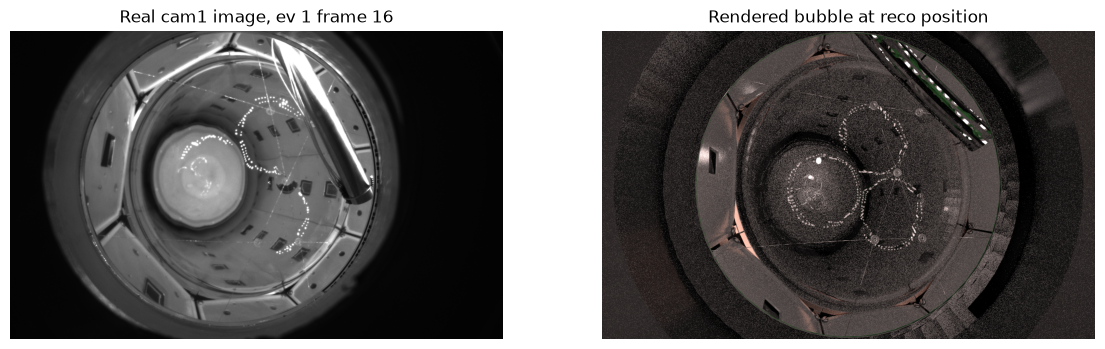

In [8]:
# Sanity check: show the actual camera frame the reco/track came from next to the render,
# and save it into the same per-frame event folder as the renders above.
real_image = load_image(rdl.camera_image_path(run_dir, ev, camera, frame))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(real_image, cmap='gray')
axes[0].set_title(f"Real cam{camera} image, ev {ev} frame {frame}")
axes[1].imshow(image**(1/2.2))
axes[1].set_title("Rendered bubble at reco position")
for ax in axes:
    ax.axis('off')

compare_path = dest_dir / f"{time.strftime('%H_%M_%S')}_comparison_{tag}.png"
fig.savefig(compare_path, dpi=150, bbox_inches='tight')
print('Saved Image:', compare_path)